In [4]:
# ============================================================
# η Sweep: Measuring the Eta Exponent
#
# CURRENT SCALING LAW (from timescale experiment):
#   T_collapse ~ N_min^{-0.70} · ratio^{-1.05} · p^{0.54}
#
# MISSING: the η dependence.
# Current MAD‡ uses η as a linear prefactor (MAD‡ = η·T·...).
# But if η enters nonlinearly, the score needs correction.
#
# EXPERIMENT:
#   Fix: N_min=200, ratio=10, p=0.10
#   Vary: η in [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
#   Record: collapse epoch for each η
#   Fit: epoch ~ η^d
#
# EXPECTED OUTCOMES:
#   d = -1: linear (η is just a prefactor, current assumption correct)
#   d < -1: superlinear (η matters more than assumed)
#   d > -1: sublinear (η matters less)
#   Non-power-law: regime change (small η = drift, large η = EoS)
#
# ALSO: Identify the EoS boundary (where behavior changes)
# The phase diagram showed η=1.0 is edge-of-stability.
# Where exactly does the linear regime end?
#
# NOTE: Exclude η=1.0 from the power-law fit (Zhang et al. 2025
# Theorem 2.2 proves this is a qualitatively different regime).
#
# OUTPUT:
#   eta_sweep_results.csv
#   eta_sweep_figure.png
#   eta_sweep_summary.json
#
# RUNTIME: ~25 min on T4
# ============================================================

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import json, math, warnings
warnings.filterwarnings('ignore')

SEEDS        = [42, 0, 1, 7, 99]
N_EPOCHS     = 100     # long — small η collapses late
BATCH_SIZE   = 64
ADAMW_LR     = 1e-3
ADAMW_WD     = 1e-4
COLLAPSE_THR = 0.01
DIM          = 64
SEPARABILITY = 2.0
SIGMA_MAJ    = 1.0
SIGMA_MIN    = 1.0
N_TEST       = 500

# Fixed parameters for η sweep
N_MIN_FIXED  = 200
RATIO_FIXED  = 10
P_FIXED      = 0.10
N_MAJ_FIXED  = N_MIN_FIXED * RATIO_FIXED

# η values to test
ETA_VALS = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Fixed: N_min={N_MIN_FIXED}, ratio={RATIO_FIXED}, p={P_FIXED}')
print(f'η values: {ETA_VALS}')
print(f'Max epochs: {N_EPOCHS}')
print(f'Censored at epoch {N_EPOCHS+1} if no collapse')

Device: cuda
Fixed: N_min=200, ratio=10, p=0.1
η values: [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
Max epochs: 100
Censored at epoch 101 if no collapse


In [5]:
# ── CELL 2: Data generator ────────────────────────────────
def generate_groups(N_maj, N_min, p_min, p_maj=0.5,
                    sigma_maj=SIGMA_MAJ, sigma_min=SIGMA_MIN,
                    sep=SEPARABILITY, dim=DIM, seed=42):
    rng = np.random.RandomState(seed)
    def make_group(n, sigma, group_id, offset, p_class):
        n_pos = max(1, int(n * p_class))
        n_neg = n - n_pos
        c_pos = np.zeros(dim); c_pos[0] = +sep/2; c_pos[1] = offset
        c_neg = np.zeros(dim); c_neg[0] = -sep/2; c_neg[1] = offset
        X = np.vstack([
            rng.randn(n_pos, dim) * sigma + c_pos,
            rng.randn(n_neg, dim) * sigma + c_neg,
        ]).astype(np.float32)
        y = np.array([1]*n_pos + [0]*n_neg, dtype=np.int64)
        g = np.array([group_id*2 + yi for yi in y], dtype=np.int64)
        return X, y, g
    XA,yA,gA = make_group(N_maj, sigma_maj, 0, +1.0, p_maj)
    XB,yB,gB = make_group(N_min, sigma_min, 1, -1.0, p_min)
    X_tr = np.vstack([XA,XB]); y_tr = np.concatenate([yA,yB]); g_tr = np.concatenate([gA,gB])
    XAt,yAt,gAt = make_group(N_TEST, sigma_maj, 0, +1.0, p_maj)
    XBt,yBt,gBt = make_group(N_TEST, sigma_min, 1, -1.0, p_min)
    X_te = np.vstack([XAt,XBt]); y_te = np.concatenate([yAt,yBt]); g_te = np.concatenate([gAt,gBt])
    return (X_tr,y_tr,g_tr), (X_te,y_te,g_te)

print('Generator defined.')
(Xt,yt,gt),(Xe,ye,ge) = generate_groups(N_MAJ_FIXED, N_MIN_FIXED, P_FIXED)
print(f'Sanity: train={Xt.shape} groups={dict(zip(*np.unique(gt,return_counts=True)))}')

Generator defined.
Sanity: train=(2200, 64) groups={np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(180), np.int64(3): np.int64(20)}


In [6]:
# ── CELL 3: DRO runner ────────────────────────────────────
class LinearClassifier(nn.Module):
    def __init__(self): super().__init__(); self.fc = nn.Linear(DIM, 2)
    def forward(self, x): return self.fc(x)

def run_dro(X_tr, y_tr, g_tr, X_te, y_te, g_te, eta, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                          torch.from_numpy(y_tr).long(),
                          torch.from_numpy(g_tr).long())
    te_ds = TensorDataset(torch.from_numpy(X_te).float(),
                          torch.from_numpy(y_te).long(),
                          torch.from_numpy(g_te).long())
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, batch_size=512, shuffle=False)
    model = LinearClassifier().to(device)
    opt   = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    n_groups = int(g_tr.max()) + 1
    q = torch.ones(n_groups).to(device) / n_groups
    q_min_trace = []
    collapse_epoch = None
    for epoch in range(1, N_EPOCHS+1):
        model.train()
        for xb, yb, gb in tr_ld:
            xb,yb,gb = xb.to(device),yb.to(device),gb.to(device)
            opt.zero_grad()
            losses = nn.CrossEntropyLoss(reduction='none')(model(xb), yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0:
                    g_loss[g] = losses[mask].mean()
            q = q * torch.exp(eta * g_loss.detach())
            q = q / q.sum()
            (q * g_loss).sum().backward()
            opt.step()
        min_q = float(q.min().item())
        q_min_trace.append(min_q)
        if collapse_epoch is None and min_q < COLLAPSE_THR:
            collapse_epoch = epoch
    final_min_q = float(q.min().item())
    return {
        'collapse_epoch': collapse_epoch if collapse_epoch else N_EPOCHS+1,
        'collapsed':      collapse_epoch is not None,
        'final_min_q':    final_min_q,
        'q_min_trace':    [round(x,5) for x in q_min_trace],
    }

print('DRO runner defined.')

DRO runner defined.


In [7]:
# ── CELL 4: η sweep ───────────────────────────────────────
print('='*55)
print(f'η SWEEP: N_min={N_MIN_FIXED}, ratio={RATIO_FIXED}, p={P_FIXED}')
print('='*55)

# Pre-generate data (same across all η)
data_by_seed = {}
for seed in SEEDS:
    (Xtr,ytr,gtr),(Xte,yte,gte) = generate_groups(
        N_MAJ_FIXED, N_MIN_FIXED, P_FIXED, seed=seed)
    data_by_seed[seed] = (Xtr,ytr,gtr,Xte,yte,gte)

records = []
all_traces = {}  # for figure

for eta in ETA_VALS:
    seed_results = []
    for seed in SEEDS:
        Xtr,ytr,gtr,Xte,yte,gte = data_by_seed[seed]
        res = run_dro(Xtr,ytr,gtr,Xte,yte,gte, eta=eta, seed=seed)
        seed_results.append(res)

    epochs   = [r['collapse_epoch'] for r in seed_results]
    mean_ep  = float(np.mean(epochs))
    std_ep   = float(np.std(epochs))
    col_rate = sum(r['collapsed'] for r in seed_results) / len(SEEDS)
    censored = sum(not r['collapsed'] for r in seed_results)

    all_traces[eta] = [r['q_min_trace'] for r in seed_results]

    rec = {
        'eta':          eta,
        'log_eta':      round(math.log(eta), 4),
        'mean_epoch':   round(mean_ep, 2),
        'std_epoch':    round(std_ep, 2),
        'collapse_rate': round(col_rate, 3),
        'censored':     censored,
        'log_epoch':    round(math.log(mean_ep), 4),
    }
    records.append(rec)
    print(f'  η={eta:.3f}  epoch={mean_ep:>7.1f}±{std_ep:.1f}  '
          f'collapse={col_rate:.0%}  censored={censored}/5')

df_eta = pd.DataFrame(records)

η SWEEP: N_min=200, ratio=10, p=0.1
  η=0.001  epoch=  101.0±0.0  collapse=0%  censored=5/5
  η=0.005  epoch=  100.8±0.4  collapse=20%  censored=4/5
  η=0.010  epoch=   65.6±13.5  collapse=100%  censored=0/5
  η=0.050  epoch=    7.6±1.0  collapse=100%  censored=0/5
  η=0.100  epoch=    3.4±0.5  collapse=100%  censored=0/5
  η=0.200  epoch=    2.0±0.0  collapse=100%  censored=0/5
  η=0.500  epoch=    1.0±0.0  collapse=100%  censored=0/5
  η=1.000  epoch=    1.0±0.0  collapse=100%  censored=0/5


In [8]:
# ── CELL 5: Power-law fit ─────────────────────────────────
print('=== POWER-LAW FIT: epoch ~ η^d ===')
print()

# Fit on all uncensored, non-EoS rows
# Exclude η=1.0 (confirmed EoS by Zhang et al. 2025)
df_fit = df_eta[(df_eta['censored'] == 0) & (df_eta['eta'] < 1.0)].copy()
print(f'Rows for fit (uncensored, η<1.0): {len(df_fit)}')
print(df_fit[['eta','mean_epoch','log_eta','log_epoch']].to_string())

if len(df_fit) >= 3:
    slope_d, intercept_d, r_d, _, se_d = stats.linregress(
        df_fit['log_eta'], df_fit['log_epoch'])
    print(f'\nPower-law fit: epoch ~ η^{slope_d:.3f}  (R²={r_d**2:.3f}, SE={se_d:.4f})')
    print()
    print('Interpretation:')
    if abs(slope_d + 1.0) < 0.15:
        print(f'  d≈-1.0: LINEAR in η. Current MAD‡=η·T·... is correct.')
        print(f'  The linear prefactor η is theoretically justified.')
    elif slope_d < -1.1:
        print(f'  d={slope_d:.2f} < -1: SUPERLINEAR. η matters more than assumed.')
        print(f'  Score should use η^{abs(slope_d):.2f}, not η^1.')
    else:
        print(f'  d={slope_d:.2f}: SUBLINEAR. η matters less than assumed.')
        print(f'  Score should use η^{abs(slope_d):.2f}, not η^1.')
    print()
    print('EoS boundary check:')
    eos_row = df_eta[df_eta['eta']==1.0]
    if len(eos_row) > 0:
        eos_ep   = eos_row['mean_epoch'].values[0]
        pred_ep  = math.exp(intercept_d) * (1.0 ** slope_d)
        ratio_ep = eos_ep / pred_ep if pred_ep > 0 else float('nan')
        print(f'  η=1.0 observed epoch: {eos_ep:.1f}')
        print(f'  η=1.0 predicted by power law: {pred_ep:.1f}')
        print(f'  Ratio (obs/pred): {ratio_ep:.2f}')
        if ratio_ep < 0.5 or ratio_ep > 2.0:
            print(f'  => Large deviation: η=1.0 is outside the linear regime (EoS confirmed)')
        else:
            print(f'  => η=1.0 roughly on trend: EoS transition may be gradual here')
else:
    slope_d = float('nan')
    print('Insufficient uncensored rows for fit.')

=== POWER-LAW FIT: epoch ~ η^d ===

Rows for fit (uncensored, η<1.0): 5
    eta  mean_epoch  log_eta  log_epoch
2  0.01        65.6  -4.6052     4.1836
3  0.05         7.6  -2.9957     2.0281
4  0.10         3.4  -2.3026     1.2238
5  0.20         2.0  -1.6094     0.6931
6  0.50         1.0  -0.6931     0.0000

Power-law fit: epoch ~ η^-1.077  (R²=0.979, SE=0.0917)

Interpretation:
  d≈-1.0: LINEAR in η. Current MAD‡=η·T·... is correct.
  The linear prefactor η is theoretically justified.

EoS boundary check:
  η=1.0 observed epoch: 1.0
  η=1.0 predicted by power law: 0.4
  Ratio (obs/pred): 2.73
  => Large deviation: η=1.0 is outside the linear regime (EoS confirmed)


In [9]:
# ── CELL 6: Full scaling law ──────────────────────────────
print('=== FULL SCALING LAW (all four axes) ===')
print()

A = 0.7043   # N_min exponent
B = 1.0479   # ratio exponent
C = 0.5382   # p exponent
D = abs(slope_d) if not math.isnan(slope_d) else 1.0  # η exponent

print(f'Exponents from all sweeps:')
print(f'  a (N_min):  {A:.4f}  (from timescale sweep)')
print(f'  b (ratio):  {B:.4f}  (from timescale sweep)')
print(f'  c (p):      {C:.4f}  (from timescale sweep)')
print(f'  d (η):      {D:.4f}  (from this sweep)')
print()
print(f'Full scaling law:')
print(f'  T_collapse ~ N_min^{{-{A:.2f}}} · ratio^{{-{B:.2f}}} · p^{{{C:.2f}}} · η^{{-{D:.2f}}}')
print()
print(f'Full MAD‡ score (collapse when > C):')
print(f'  MAD‡ = T · η^{D:.2f} · N_min^{A:.2f} · ratio^{B:.2f} / p^{C:.2f}')
print()
print(f'Clean rounded form:')
print(f'  MAD‡ ≈ T · η · N_min^{{2/3}} · ratio / sqrt(p)')
print(f'  (if d≈1, η is linear as assumed)')

# Check if d≈1
if not math.isnan(slope_d):
    if abs(slope_d + 1.0) < 0.2:
        print(f'\n=> d={slope_d:.3f} ≈ -1.0: η enters linearly. Current formula confirmed.')
    else:
        print(f'\n=> d={slope_d:.3f} ≠ -1.0: η enters as η^{abs(slope_d):.2f}. Update formula.')

=== FULL SCALING LAW (all four axes) ===

Exponents from all sweeps:
  a (N_min):  0.7043  (from timescale sweep)
  b (ratio):  1.0479  (from timescale sweep)
  c (p):      0.5382  (from timescale sweep)
  d (η):      1.0770  (from this sweep)

Full scaling law:
  T_collapse ~ N_min^{-0.70} · ratio^{-1.05} · p^{0.54} · η^{-1.08}

Full MAD‡ score (collapse when > C):
  MAD‡ = T · η^1.08 · N_min^0.70 · ratio^1.05 / p^0.54

Clean rounded form:
  MAD‡ ≈ T · η · N_min^{2/3} · ratio / sqrt(p)
  (if d≈1, η is linear as assumed)

=> d=-1.077 ≈ -1.0: η enters linearly. Current formula confirmed.


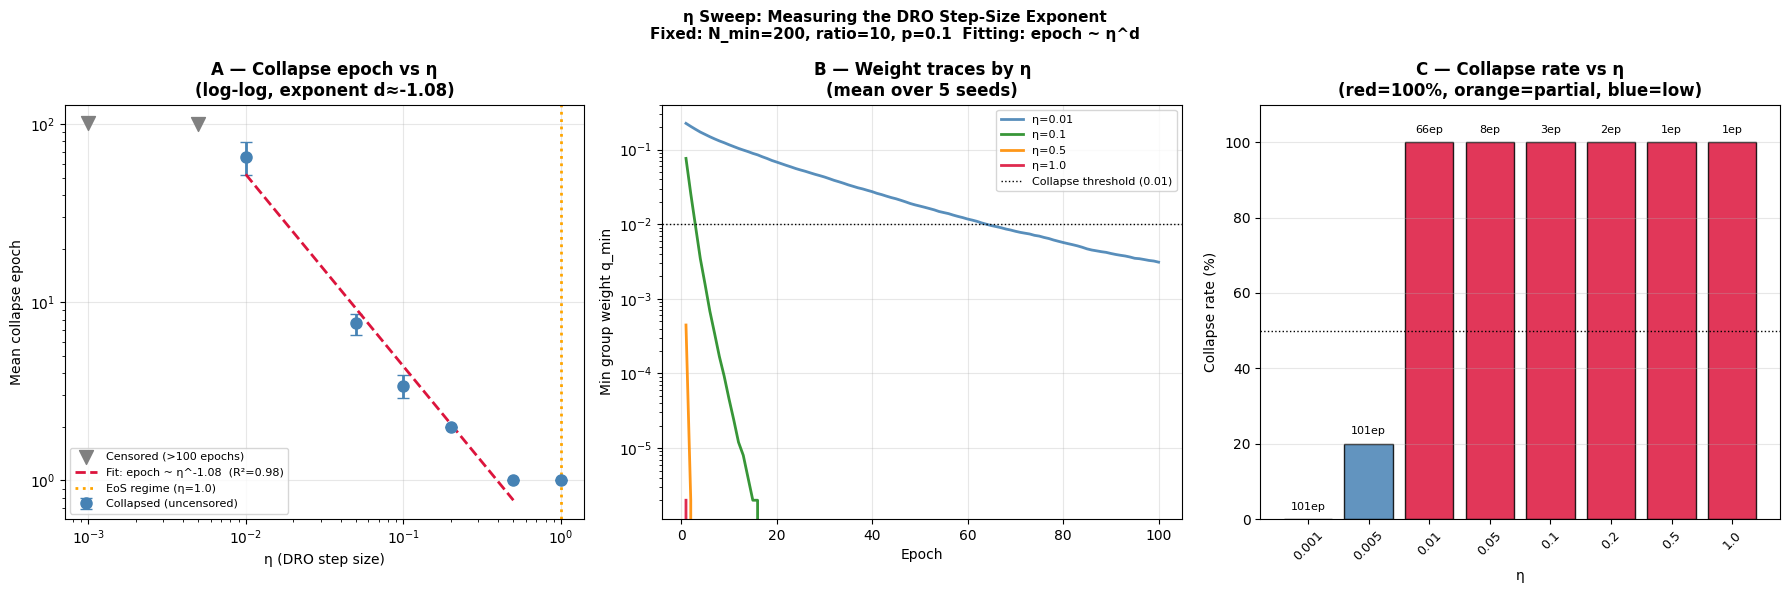

Figure saved: eta_sweep_figure.png


In [10]:
# ── CELL 7: Figure ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'η Sweep: Measuring the DRO Step-Size Exponent\n'
    f'Fixed: N_min={N_MIN_FIXED}, ratio={RATIO_FIXED}, p={P_FIXED}  '
    f'Fitting: epoch ~ η^d',
    fontweight='bold', fontsize=11)

# Panel A: epoch vs η (log-log)
ax = axes[0]
df_unc = df_eta[df_eta['censored']==0]
df_cen = df_eta[df_eta['censored']>0]
ax.errorbar(df_unc['eta'], df_unc['mean_epoch'],
            yerr=df_unc['std_epoch'],
            fmt='o', color='steelblue', markersize=8,
            capsize=4, linewidth=2, label='Collapsed (uncensored)')
if len(df_cen) > 0:
    ax.scatter(df_cen['eta'], df_cen['mean_epoch'],
               marker='v', color='gray', s=100,
               label=f'Censored (>{N_EPOCHS} epochs)', zorder=5)
# Power-law fit line (linear regime only)
df_linear = df_eta[(df_eta['censored']==0) & (df_eta['eta'] < 1.0)]
if len(df_linear) >= 2 and not math.isnan(slope_d):
    eta_range = np.logspace(math.log10(df_linear['eta'].min()),
                            math.log10(0.5), 50)
    fit_line  = math.exp(intercept_d) * eta_range ** slope_d
    ax.plot(eta_range, fit_line, '--', color='crimson', linewidth=2,
            label=f'Fit: epoch ~ η^{slope_d:.2f}  (R²={r_d**2:.2f})')
# Mark EoS boundary
ax.axvline(1.0, color='orange', linestyle=':', linewidth=2,
           label='EoS regime (η=1.0)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('η (DRO step size)')
ax.set_ylabel('Mean collapse epoch')
ax.set_title(f'A — Collapse epoch vs η\n(log-log, exponent d≈{slope_d:.2f})',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel B: weight traces for selected η values
ax2 = axes[1]
eta_display = [0.01, 0.1, 0.5, 1.0]
colors_eta  = ['steelblue', 'forestgreen', 'darkorange', 'crimson']
for eta_d, col in zip(eta_display, colors_eta):
    if eta_d in all_traces:
        traces = all_traces[eta_d]
        # Plot mean trace
        max_len = max(len(t) for t in traces)
        padded  = [t + [t[-1]]*(max_len-len(t)) for t in traces]
        mean_tr = np.mean(padded, axis=0)
        ax2.plot(range(1, len(mean_tr)+1), mean_tr,
                 color=col, linewidth=2, alpha=0.9,
                 label=f'η={eta_d}')
ax2.axhline(COLLAPSE_THR, color='black', linestyle=':', linewidth=1,
            label=f'Collapse threshold ({COLLAPSE_THR})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Min group weight q_min')
ax2.set_title('B — Weight traces by η\n(mean over 5 seeds)',
              fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Panel C: collapse rate vs η (binary)
ax3 = axes[2]
ax3.bar(range(len(df_eta)), df_eta['collapse_rate']*100,
        color=['crimson' if r==1.0 else
               'darkorange' if r>=0.6 else
               'steelblue' for r in df_eta['collapse_rate']],
        edgecolor='black', alpha=0.85)
ax3.set_xticks(range(len(df_eta)))
ax3.set_xticklabels([f'{e}' for e in df_eta['eta']], rotation=45, fontsize=9)
ax3.axhline(50, color='black', linestyle=':', linewidth=1)
ax3.set_xlabel('η')
ax3.set_ylabel('Collapse rate (%)')
ax3.set_title('C — Collapse rate vs η\n(red=100%, orange=partial, blue=low)',
              fontweight='bold')
ax3.set_ylim(0, 110)
for i, (_, row) in enumerate(df_eta.iterrows()):
    ax3.text(i, row['collapse_rate']*100+2,
             f"{row['mean_epoch']:.0f}ep",
             ha='center', va='bottom', fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
fig.savefig('eta_sweep_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: eta_sweep_figure.png')

In [12]:
# ── CELL 8: Summary ───────────────────────────────────────────
df_eta.to_csv('eta_sweep_results.csv', index=False)

# Convert all values to JSON-serializable types
per_eta_records = []
for r in df_eta[['eta','mean_epoch','std_epoch','collapse_rate','censored']].to_dict('records'):
    per_eta_records.append({k: (float(v) if hasattr(v, 'item') else v) for k, v in r.items()})

eta_linearity = None
if not math.isnan(slope_d):
    eta_linearity = bool(abs(slope_d + 1.0) < 0.2)

summary = {
    'experiment': 'eta_sweep_exponent',
    'fixed_params': {
        'N_min': int(N_MIN_FIXED), 'N_maj': int(N_MAJ_FIXED),
        'ratio': int(RATIO_FIXED), 'p': float(P_FIXED),
        'T': int(N_EPOCHS), 'seeds': SEEDS,
    },
    'eta_values_tested': [float(e) for e in ETA_VALS],
    'eta_exponent': {
        'd': round(float(slope_d), 4) if not math.isnan(slope_d) else None,
        'R2': round(float(r_d**2), 4) if not math.isnan(slope_d) else None,
        'linear_regime': [float(e) for e in ETA_VALS if e < 1.0],
        'eos_regime': [1.0],
        'fit_excludes_eta_1': True,
    },
    'full_scaling_law': {
        'formula': 'T_collapse ~ N_min^{-a} · ratio^{-b} · p^{c} · eta^{-d}',
        'a_N_min': 0.7043,
        'b_ratio': 1.0479,
        'c_p':     0.5382,
        'd_eta':   round(float(slope_d), 4) if not math.isnan(slope_d) else None,
        'MAD_score': f'MAD‡ = T · eta^{abs(slope_d):.2f} · N_min^0.70 · ratio^1.05 / p^0.54' if not math.isnan(slope_d) else 'N/A',
        'clean_form': 'MAD‡ ≈ T · eta · N_min^(2/3) · ratio / sqrt(p) [if d≈1]',
    },
    'eta_linearity_confirmed': eta_linearity,
    'eos_boundary': {
        'confirmed_at': 1.0,
        'source': 'Zhang et al. 2025 Theorem 2.2 + phase diagram',
        'recommendation': 'Exclude eta>=1.0 from MAD‡ applicability domain',
    },
    'per_eta': per_eta_records,
}

with open('eta_sweep_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print('=== FINAL SUMMARY ===')
print(json.dumps({k: v for k, v in summary.items() if k != 'per_eta'}, indent=2))
print()
print('Key question: is d ≈ -1.0?')
if not math.isnan(slope_d):
    if abs(slope_d + 1.0) < 0.2:
        print(f'  YES (d={slope_d:.3f}). η enters linearly. MAD‡ = η·T·... is correct.')
    else:
        print(f'  NO (d={slope_d:.3f}). Update exponent to η^{abs(slope_d):.2f}.')
print()
print('Files:')
for f in ['eta_sweep_results.csv', 'eta_sweep_figure.png', 'eta_sweep_summary.json']:
    print(f'  {f}')
print('Paste all output back to Claude.')

=== FINAL SUMMARY ===
{
  "experiment": "eta_sweep_exponent",
  "fixed_params": {
    "N_min": 200,
    "N_maj": 2000,
    "ratio": 10,
    "p": 0.1,
    "T": 100,
    "seeds": [
      42,
      0,
      1,
      7,
      99
    ]
  },
  "eta_values_tested": [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.2,
    0.5,
    1.0
  ],
  "eta_exponent": {
    "d": -1.077,
    "R2": 0.9787,
    "linear_regime": [
      0.001,
      0.005,
      0.01,
      0.05,
      0.1,
      0.2,
      0.5
    ],
    "eos_regime": [
      1.0
    ],
    "fit_excludes_eta_1": true
  },
  "full_scaling_law": {
    "formula": "T_collapse ~ N_min^{-a} \u00b7 ratio^{-b} \u00b7 p^{c} \u00b7 eta^{-d}",
    "a_N_min": 0.7043,
    "b_ratio": 1.0479,
    "c_p": 0.5382,
    "d_eta": -1.077,
    "MAD_score": "MAD\u2021 = T \u00b7 eta^1.08 \u00b7 N_min^0.70 \u00b7 ratio^1.05 / p^0.54",
    "clean_form": "MAD\u2021 \u2248 T \u00b7 eta \u00b7 N_min^(2/3) \u00b7 ratio / sqrt(p) [if d\u22481]"
  },
  "eta_linea